# Forest Covertype — Boostwatch Analysis

Multi-class classification on the [Forest Covertype](https://archive.ics.uci.edu/dataset/31/covertype) dataset — one of the richest tabular datasets available for gradient boosting benchmarks.

| Property | Value |
|---|---|
| **Rows** | 581,012 (80K sample used here) |
| **Features** | 54 (10 continuous + 44 binary) |
| **Task** | 7-class classification (forest cover types) |
| **Source** | UCI ML Repository via `sklearn.datasets.fetch_covtype` |

The 54 features include cartographic variables such as elevation, aspect, slope, distances to hydrology/roads/fire points, hillshade indices, 4 wilderness area indicators, and 40 soil type indicators.

## What this notebook covers
1. Downloading & exploring the dataset (no authentication needed)
2. Multi-class training with LightGBM + boostwatch
3. Feature importance across all 54 features
4. Tree complexity with multi-class boosting (7 trees per iteration)
5. Leaf and split depth analysis
6. Per-class confidence analysis

## Setup

In [1]:
# Uncomment to install:
# pip install boostwatch[lightgbm]

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_covtype
import lightgbm as lgb

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from boostwatch import watch
from boostwatch.viz.themes import apply_theme
from boostwatch.analysis.tree_analysis import (
    compute_tree_stats,
    compute_split_depth_distribution,
    compute_leaf_distribution,
)

apply_theme('default')
print(f'LightGBM {lgb.__version__}')
print('Boostwatch ready')

LightGBM 4.6.0
Boostwatch ready


## 1. Download the Dataset

`fetch_covtype` downloads and caches the dataset automatically (`~/scikit_learn_data/`). We draw a stratified 80K sample for training speed — the full 581K dataset can be used by removing the sampling step.

In [2]:
print('Downloading Forest Covertype from sklearn...')
cov = fetch_covtype(as_frame=True)
X_full = cov.data
y_full = cov.target

print(f'Full dataset : {X_full.shape}')
print(f'Classes      : {sorted(y_full.unique().tolist())} (cover types 1-7)')
print(f'\nFeature groups:')
print(f'  Continuous (10) : {list(X_full.columns[:10])}')
print(f'  Binary (44)     : Wilderness_Area1-4, Soil_Type1-40')

Full dataset : (581012, 54)
Classes      : [1, 2, 3, 4, 5, 6, 7] (cover types 1-7)

Feature groups:
  Continuous (10) : ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
  Binary (44)     : Wilderness_Area1-4, Soil_Type1-40


In [3]:
# Stratified 80K sample for training speed
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_full), size=80_000, replace=False)
X = X_full.iloc[sample_idx].reset_index(drop=True)
y = y_full.iloc[sample_idx].reset_index(drop=True) - 1  # 0-indexed classes

feature_names = list(X.columns)
class_names = [f'Cover Type {i+1}' for i in range(7)]

print(f'Sample shape : {X.shape}')
print(f'\nClass distribution (sample):')
vc = y.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f'  Cover Type {cls+1}: {cnt:,} ({cnt/len(y)*100:.1f}%)')

Sample shape : (80000, 54)

Class distribution (sample):
  Cover Type 1: 29,038 (36.3%)
  Cover Type 2: 39,149 (48.9%)
  Cover Type 3: 4,878 (6.1%)
  Cover Type 4: 390 (0.5%)
  Cover Type 5: 1,315 (1.6%)
  Cover Type 6: 2,438 (3.0%)
  Cover Type 7: 2,792 (3.5%)


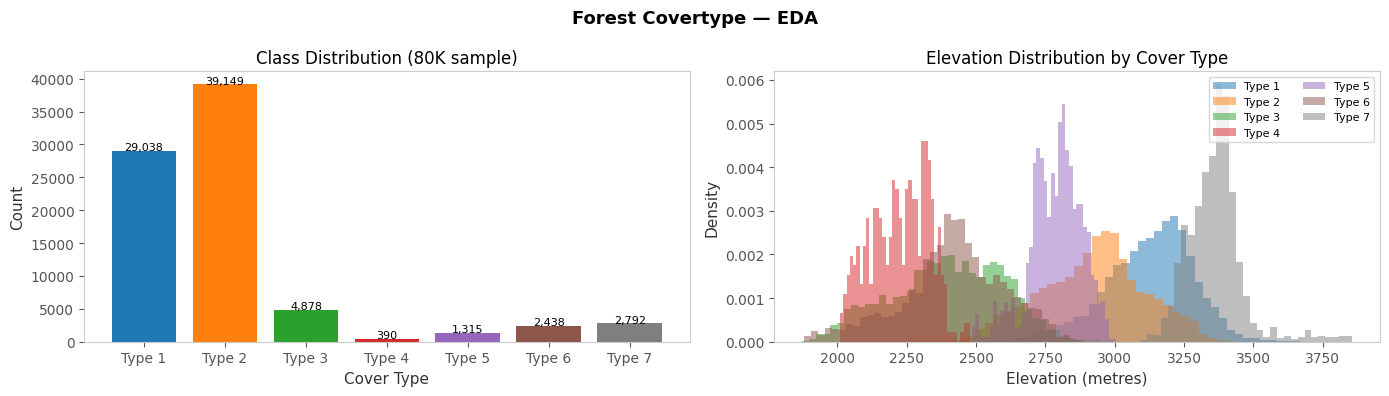

In [4]:
# EDA — class balance + continuous feature overview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
colors = cm.tab10(np.linspace(0, 0.7, 7))
vc = y.value_counts().sort_index()
bars = axes[0].bar([f'Type {i+1}' for i in vc.index], vc.values, color=colors)
axes[0].set_title('Class Distribution (80K sample)', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Cover Type')
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{v:,}', ha='center', fontsize=8)

# Elevation distribution by class (most discriminative single feature)
for cls in range(7):
    elev = X.loc[y == cls, 'Elevation']
    axes[1].hist(elev, bins=40, alpha=0.5, label=f'Type {cls+1}', color=colors[cls], density=True)
axes[1].set_title('Elevation Distribution by Cover Type', fontsize=12)
axes[1].set_xlabel('Elevation (metres)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Forest Covertype — EDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

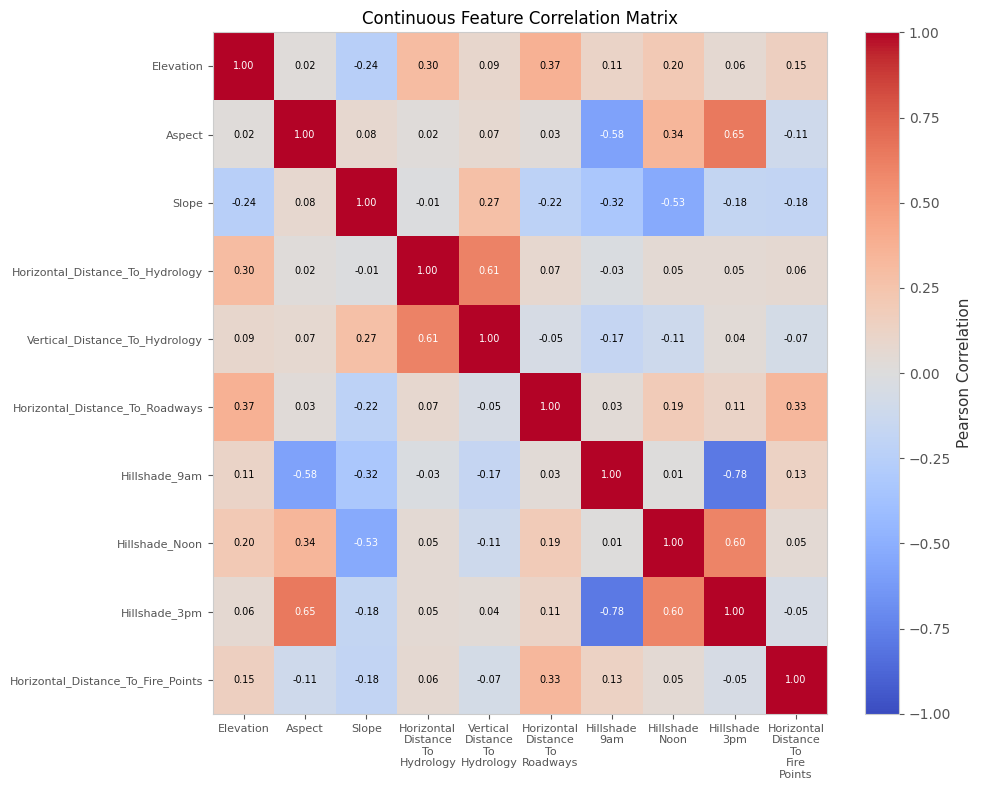

In [5]:
# Correlation heatmap — continuous features only
cont_cols = list(X.columns[:10])
corr = X[cont_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cont_cols)))
ax.set_yticks(range(len(cont_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in cont_cols], fontsize=8)
ax.set_yticklabels(cont_cols, fontsize=8)
for i in range(len(cont_cols)):
    for j in range(len(cont_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Continuous Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Training with Boostwatch (LightGBM Multi-class)

For 7-class classification, LightGBM builds **7 trees per boosting iteration** (one per class). Boostwatch captures all 7 trees per iteration, so each `IterationLog` contains a `trees` list of length 7.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

observer = watch(lgb_model, feature_names=feature_names)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=observer.callbacks(),
)

preds = lgb_model.predict(X_test)
probs = lgb_model.predict_proba(X_test)

print(f'\nIterations logged : {len(observer.get_logs())}')
print(f'Trees per iter    : {observer.get_logs()[0].num_trees} (one per class)')
print(f'Accuracy          : {accuracy_score(y_test, preds):.4f}')
print(f'\nPer-class accuracy:')
report = classification_report(y_test, preds, target_names=class_names, output_dict=True)
for cls in class_names:
    print(f'  {cls}: {report[cls]["precision"]:.3f} prec | {report[cls]["recall"]:.3f} rec | {report[cls]["f1-score"]:.3f} F1')

Train: (64000, 54)  |  Test: (16000, 54)



Iterations logged : 100
Trees per iter    : 7 (one per class)
Accuracy          : 0.8758

Per-class accuracy:
  Cover Type 1: 0.884 prec | 0.843 rec | 0.863 F1
  Cover Type 2: 0.870 prec | 0.911 rec | 0.890 F1
  Cover Type 3: 0.880 prec | 0.902 rec | 0.891 F1
  Cover Type 4: 0.758 prec | 0.641 rec | 0.694 F1
  Cover Type 5: 0.828 prec | 0.605 rec | 0.699 F1
  Cover Type 6: 0.821 prec | 0.789 rec | 0.805 F1
  Cover Type 7: 0.958 prec | 0.905 rec | 0.931 F1


## 3. Boostwatch Analysis

### 3a. Training Summary

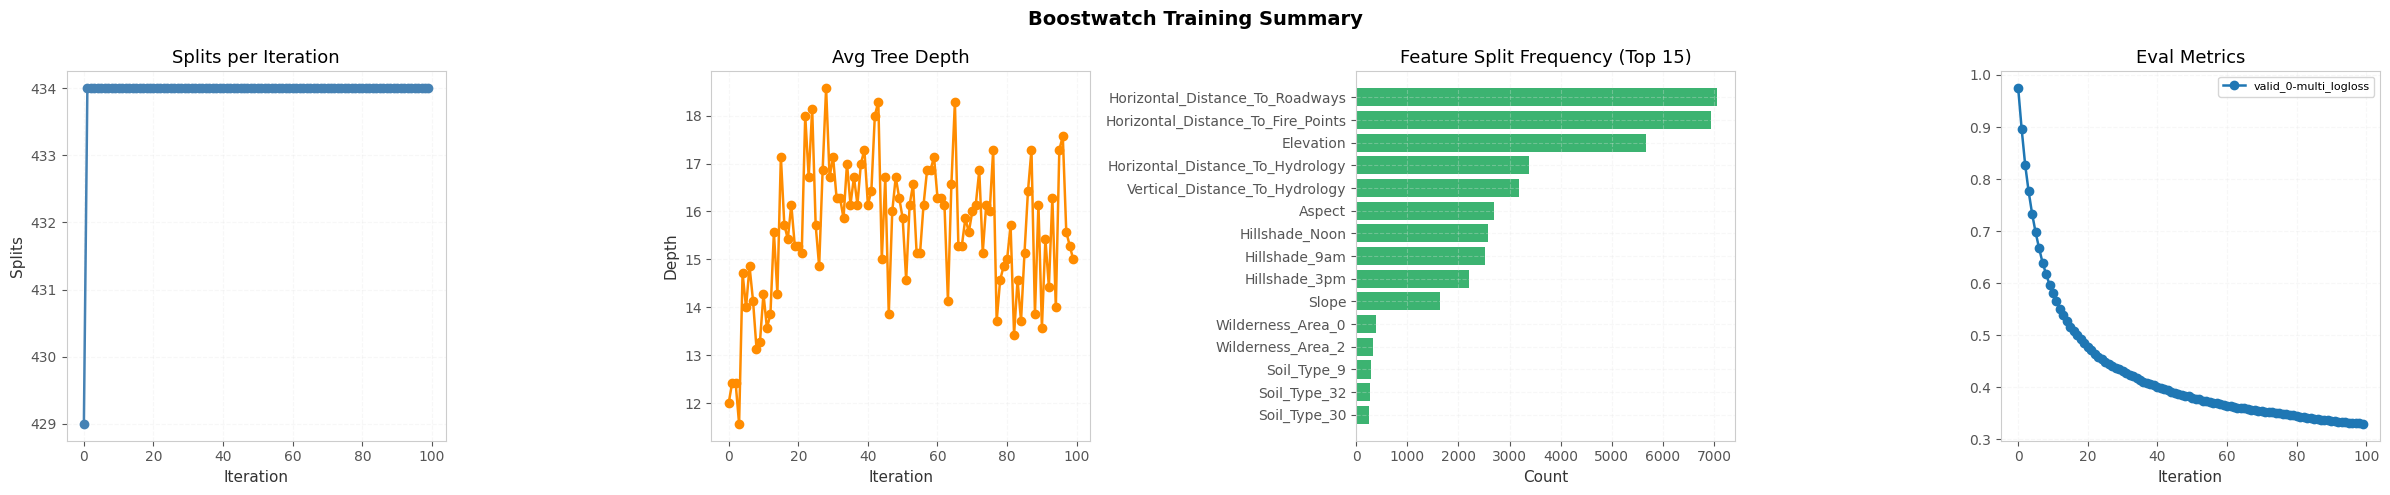

In [7]:
observer.plot_summary()

### 3b. Feature Importance — All 54 Features

With 54 features, visualising importance requires careful layout. We split into two views: **top continuous features** and **top binary features** (wilderness area + soil type indicators).

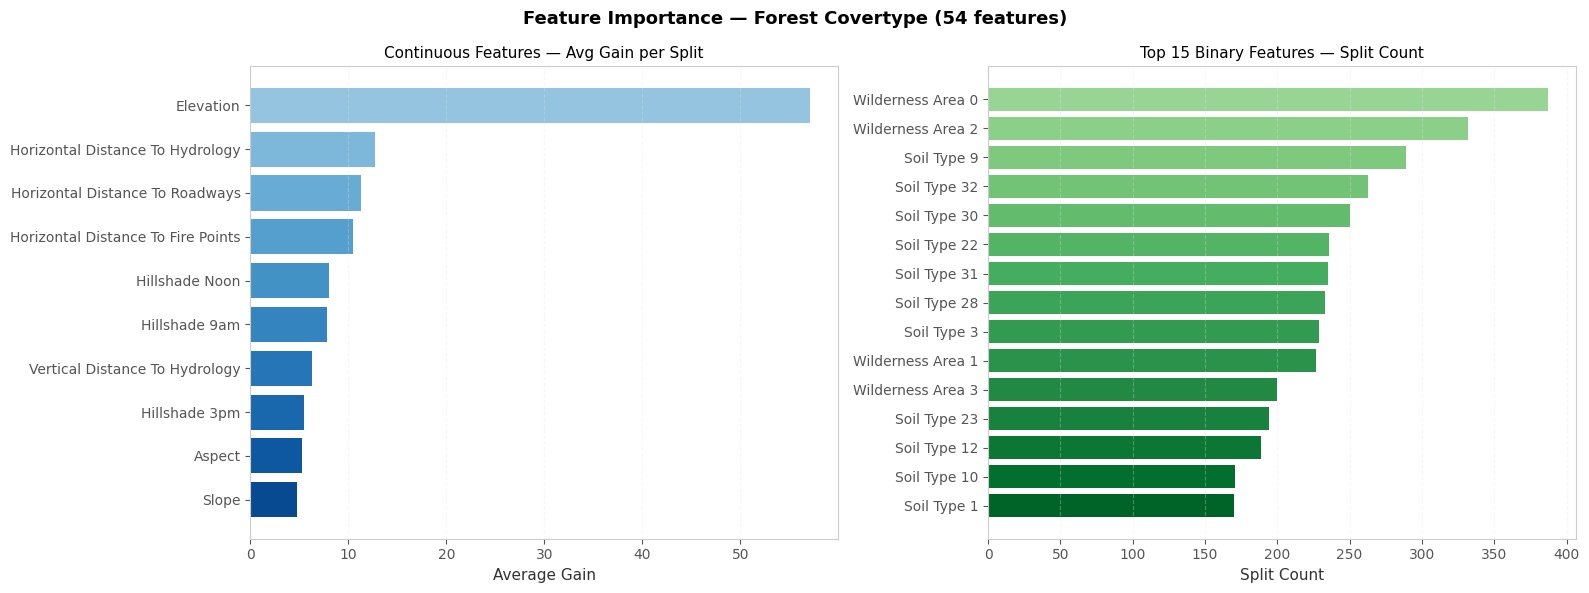

In [8]:
from boostwatch.viz.plotting import plot_feature_stats
stats = observer.feature_stats()

# Split into continuous (first 10) and binary (last 44)
cont_feat_idx = list(range(10))
bin_feat_idx  = list(range(10, 54))

# Top continuous features by avg gain
cont_sorted = sorted(
    [(i, stats[i]) for i in cont_feat_idx if i in stats],
    key=lambda x: x[1]['avg_gain'], reverse=True
)
# Top binary features by split count
bin_sorted = sorted(
    [(i, stats[i]) for i in bin_feat_idx if i in stats],
    key=lambda x: x[1]['count'], reverse=True
)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Continuous features — avg gain
names_c = [feature_names[i].replace('_', ' ') for i, _ in cont_sorted]
gains_c = [s['avg_gain'] for _, s in cont_sorted]
colors_c = cm.Blues(np.linspace(0.4, 0.9, len(names_c)))[::-1]
axes[0].barh(names_c[::-1], gains_c[::-1], color=colors_c)
axes[0].set_title('Continuous Features — Avg Gain per Split', fontsize=11)
axes[0].set_xlabel('Average Gain')
axes[0].grid(axis='x', alpha=0.3)

# Binary features — split count
names_b = [feature_names[i].replace('_', ' ') for i, _ in bin_sorted]
counts_b = [s['count'] for _, s in bin_sorted]
colors_b = cm.Greens(np.linspace(0.4, 0.9, len(names_b)))[::-1]
axes[1].barh(names_b[::-1], counts_b[::-1], color=colors_b)
axes[1].set_title('Top 15 Binary Features — Split Count', fontsize=11)
axes[1].set_xlabel('Split Count')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Forest Covertype (54 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

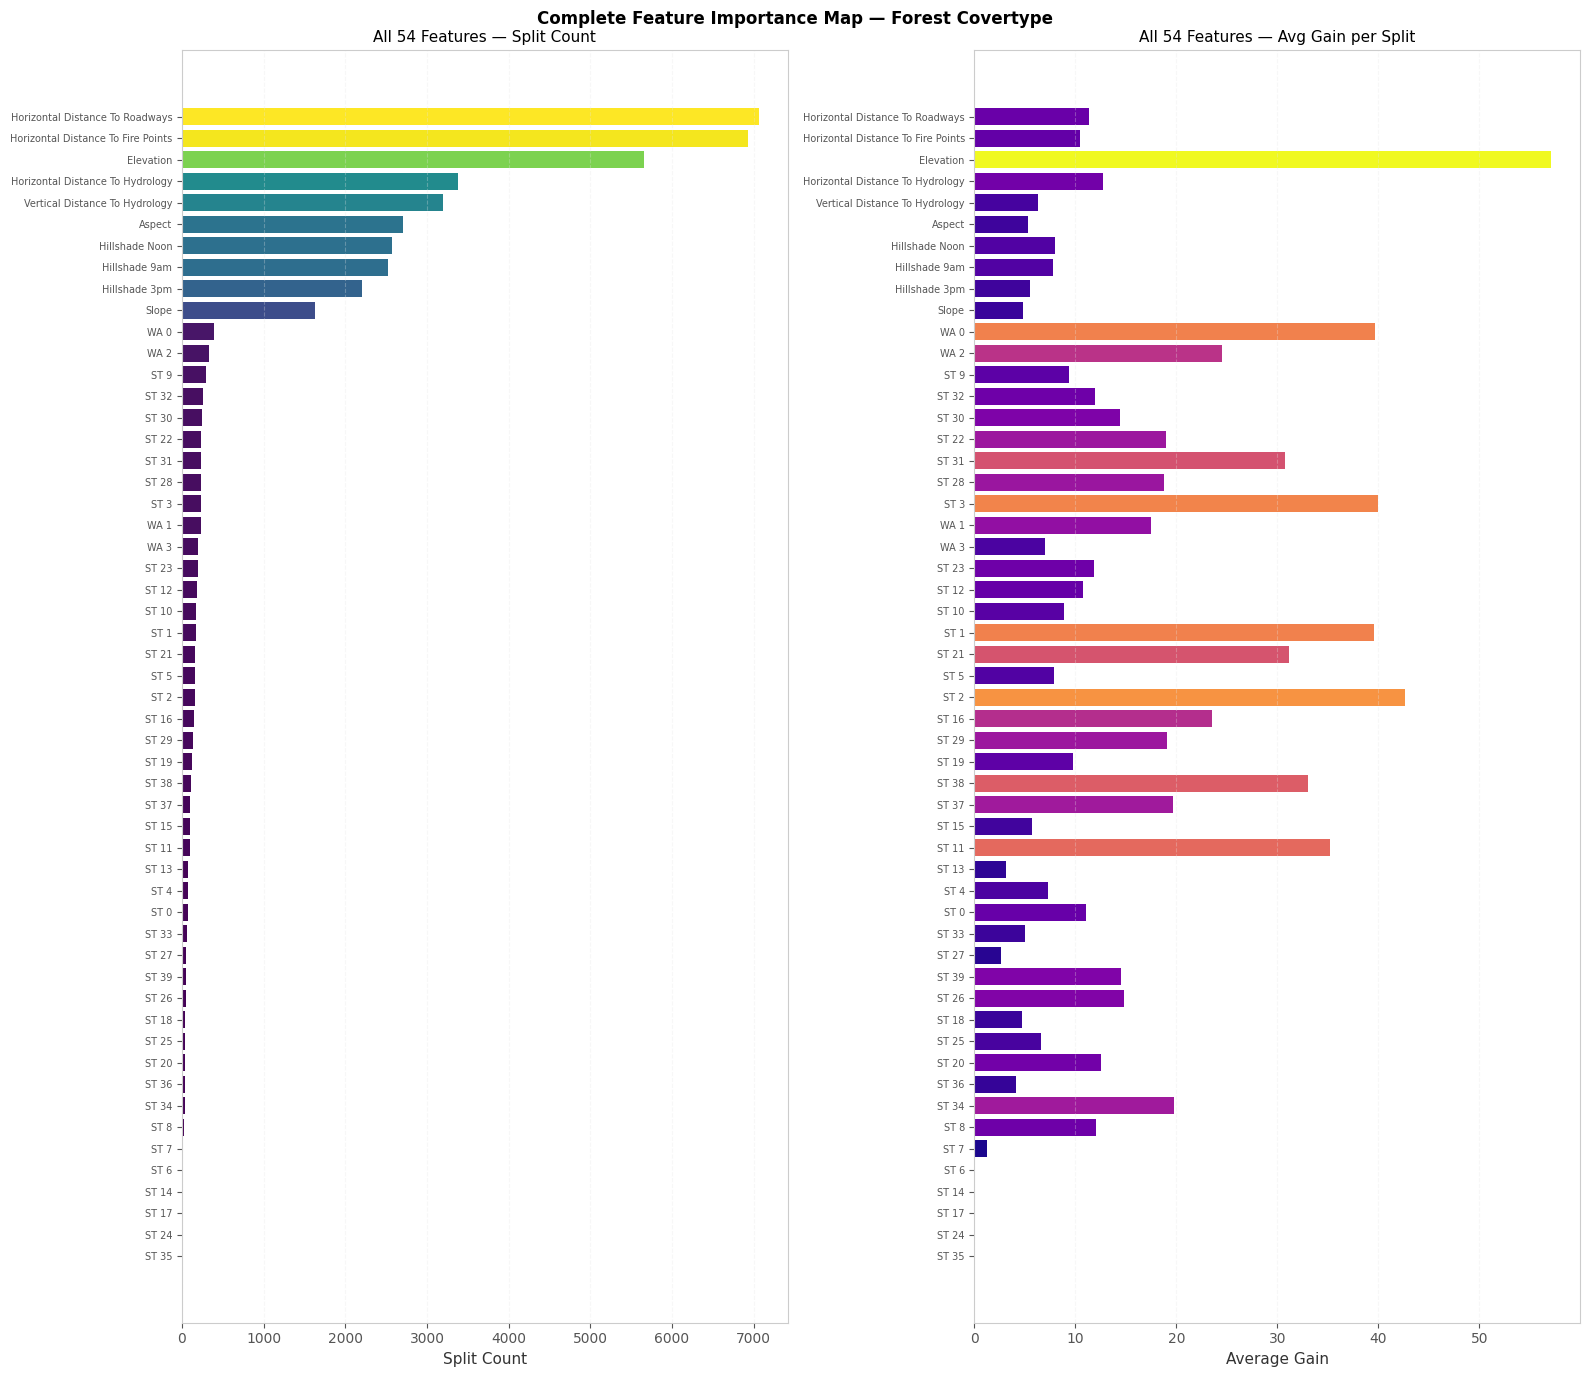

In [9]:
# All 54 features — split count heatmap style
all_sorted = sorted(stats.items(), key=lambda x: x[1]['count'], reverse=True)
all_names  = [feature_names[i].replace('Soil_Type', 'ST').replace('Wilderness_Area', 'WA').replace('_', ' ')
              for i, _ in all_sorted]
all_counts = [s['count'] for _, s in all_sorted]
all_gains  = [s['avg_gain'] for _, s in all_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 14))

colors_all = cm.viridis(np.array(all_counts) / max(all_counts))
axes[0].barh(all_names[::-1], all_counts[::-1], color=colors_all[::-1])
axes[0].set_title('All 54 Features — Split Count', fontsize=11)
axes[0].set_xlabel('Split Count')
axes[0].tick_params(axis='y', labelsize=7)
axes[0].grid(axis='x', alpha=0.3)

colors_g = cm.plasma(np.array(all_gains) / (max(all_gains) + 1e-9))
axes[1].barh(all_names[::-1], all_gains[::-1], color=colors_g[::-1])
axes[1].set_title('All 54 Features — Avg Gain per Split', fontsize=11)
axes[1].set_xlabel('Average Gain')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Complete Feature Importance Map — Forest Covertype', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Multi-class Tree Complexity

With 7 trees per iteration (one per class), the depth and leaf patterns can differ across classes. Here we aggregate across trees within each iteration.

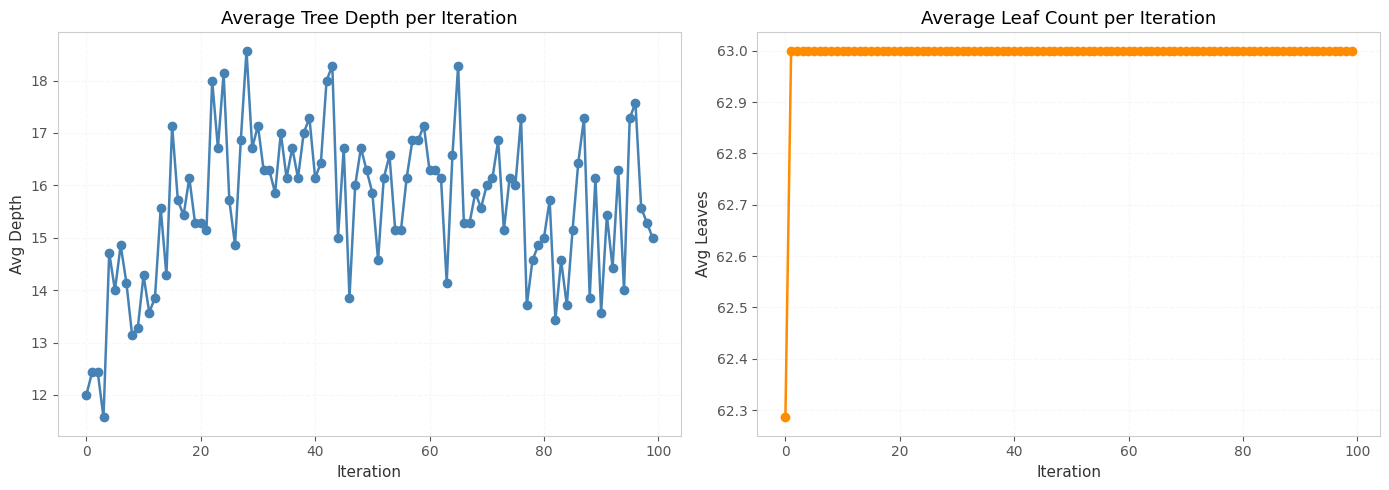

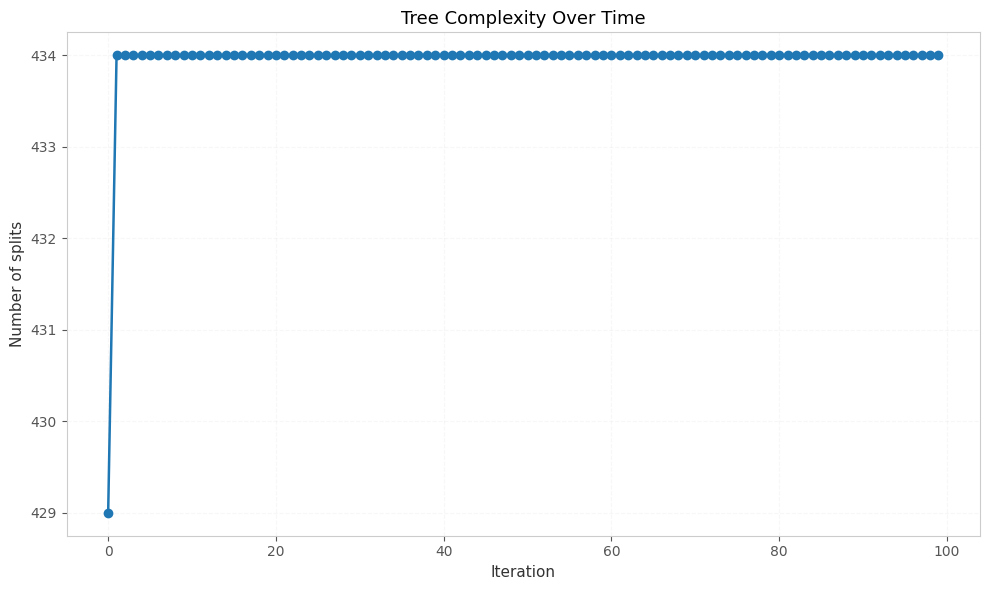

In [10]:
from boostwatch.viz.plotting import plot_tree_complexity, plot_splits_per_iteration

plot_tree_complexity(observer.get_logs())
plot_splits_per_iteration(observer.get_logs())

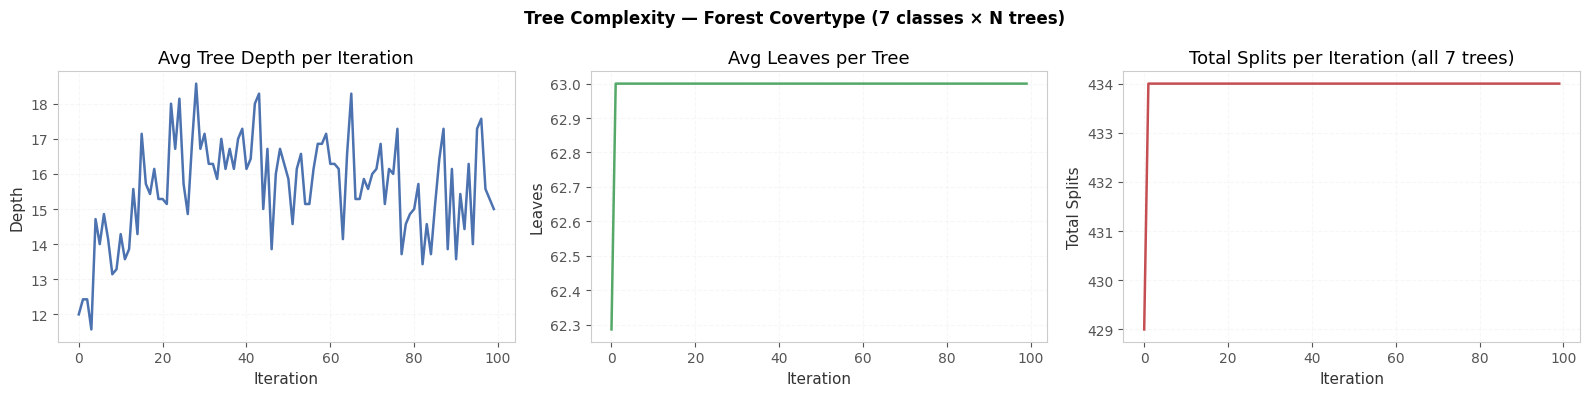

In [11]:
# Per-iteration: total splits across all 7 class trees
ts = compute_tree_stats(observer.get_logs())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ts['iterations'], ts['avg_depth'],   color='#4c72b0', linewidth=1.8)
axes[0].set_title('Avg Tree Depth per Iteration')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Depth')
axes[0].grid(alpha=0.3)

axes[1].plot(ts['iterations'], ts['avg_leaves'],  color='#55a868', linewidth=1.8)
axes[1].set_title('Avg Leaves per Tree')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Leaves')
axes[1].grid(alpha=0.3)

axes[2].plot(ts['iterations'], ts['total_splits'], color='#c44e52', linewidth=1.8)
axes[2].set_title('Total Splits per Iteration (all 7 trees)')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Total Splits')
axes[2].grid(alpha=0.3)

plt.suptitle('Tree Complexity — Forest Covertype (7 classes × N trees)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Split Depth Distribution

How deeply are splits distributed across all trees? With multi-class boosting and 54 features the model can afford to be more selective — shallow splits handle coarse discrimination, deeper ones refine class boundaries.

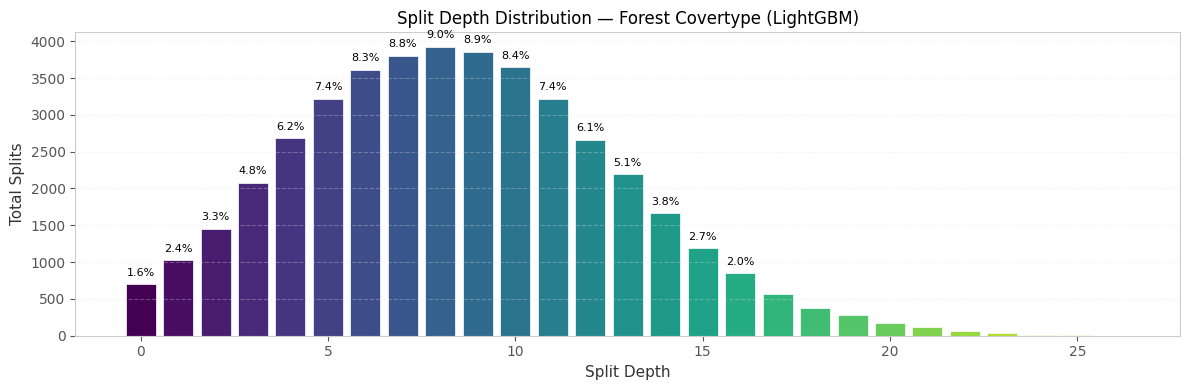

In [12]:
depth_dist = compute_split_depth_distribution(observer.get_logs())
depths = sorted(depth_dist.keys())
counts = [depth_dist[d] for d in depths]
total  = sum(counts)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(depths, counts, color=cm.viridis(np.array(depths) / max(depths)),
              edgecolor='white', linewidth=0.5)
ax.set_xlabel('Split Depth', fontsize=11)
ax.set_ylabel('Total Splits', fontsize=11)
ax.set_title('Split Depth Distribution — Forest Covertype (LightGBM)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    if pct > 1.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total * 0.002,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 3e. Leaf Analysis

Leaf values in multi-class LightGBM are small log-odds adjustments. The distribution of leaf sample counts reveals how balanced the model's partitions are across training examples.

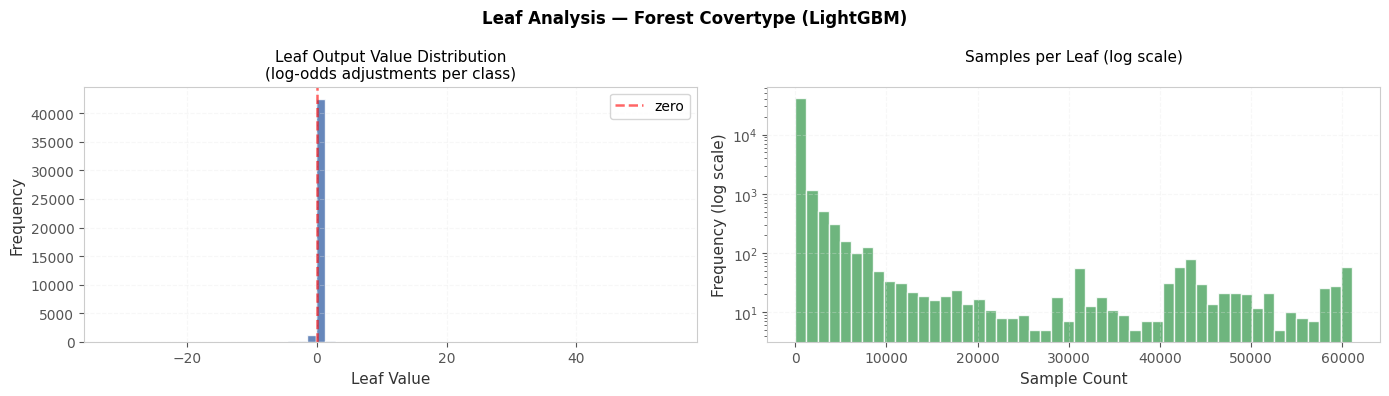

Total leaves logged  : 44,095
Avg leaf output value: -0.007102
Avg samples per leaf : 1016.0


In [13]:
leaf_data = compute_leaf_distribution(observer.get_logs())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(leaf_data['leaf_values'], bins=60, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[0].set_title('Leaf Output Value Distribution\n(log-odds adjustments per class)', fontsize=11)
axes[0].set_xlabel('Leaf Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6, label='zero')
axes[0].legend()
axes[0].grid(alpha=0.3)

nonzero_counts = [c for c in leaf_data['leaf_counts'] if c > 0]
axes[1].hist(nonzero_counts, bins=50, color='#55a868', edgecolor='white', alpha=0.85, log=True)
axes[1].set_title('Samples per Leaf (log scale)\n', fontsize=11)
axes[1].set_xlabel('Sample Count')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(alpha=0.3)

plt.suptitle('Leaf Analysis — Forest Covertype (LightGBM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total leaves logged  : {len(leaf_data["leaf_values"]):,}')
print(f'Avg leaf output value: {np.mean(leaf_data["leaf_values"]):.6f}')
print(f'Avg samples per leaf : {np.mean(nonzero_counts):.1f}')

### 3f. Per-class Confidence Analysis

For multi-class problems, the max predicted probability (confidence) tells us how certain the model is about its top prediction. Cover types with similar vegetation characteristics (e.g. Types 1 & 2 — Spruce/Fir and Lodgepole Pine) tend to produce lower confidence scores.

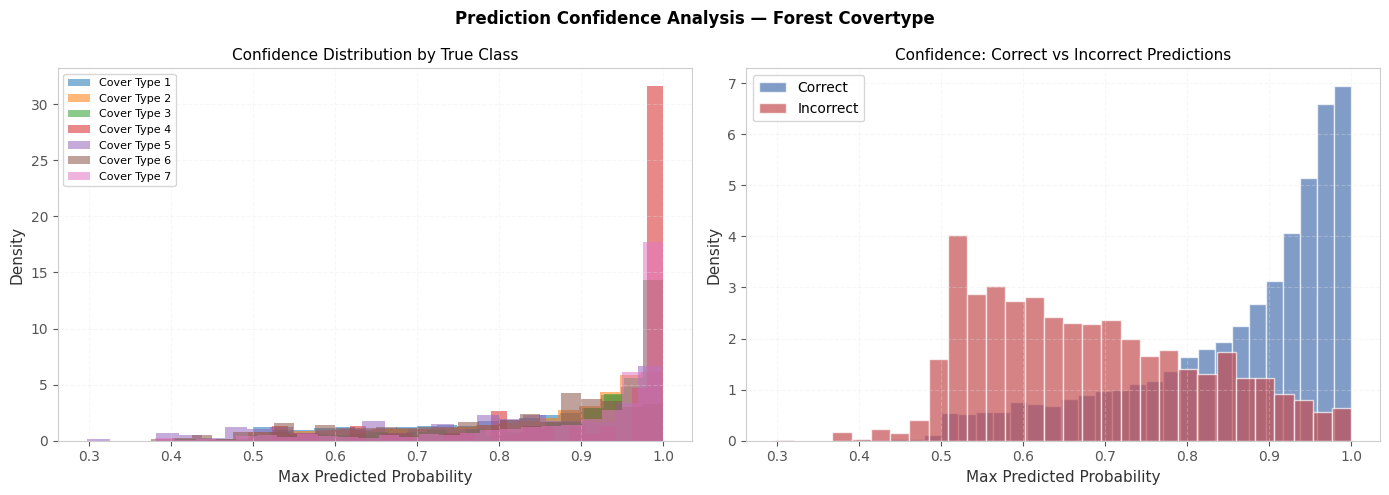

Accuracy           : 0.8758
Avg confidence     : 0.839
Avg conf (correct) : 0.862
Avg conf (wrong)   : 0.678


In [14]:
confidence = np.max(probs, axis=1)
errors     = (preds != y_test.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence by class
for cls in range(7):
    mask = y_test.values == cls
    axes[0].hist(confidence[mask], bins=25, alpha=0.55, density=True,
                 label=class_names[cls], color=cm.tab10(cls / 10))
axes[0].set_title('Confidence Distribution by True Class', fontsize=11)
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Confidence: correct vs incorrect
axes[1].hist(confidence[~errors], bins=30, alpha=0.7, density=True,
             label='Correct', color='#4c72b0', edgecolor='white')
axes[1].hist(confidence[errors],  bins=30, alpha=0.7, density=True,
             label='Incorrect', color='#c44e52', edgecolor='white')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions', fontsize=11)
axes[1].set_xlabel('Max Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Prediction Confidence Analysis — Forest Covertype', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Accuracy           : {accuracy_score(y_test, preds):.4f}')
print(f'Avg confidence     : {confidence.mean():.3f}')
print(f'Avg conf (correct) : {confidence[~errors].mean():.3f}')
print(f'Avg conf (wrong)   : {confidence[errors].mean():.3f}')

## Summary

| Insight | Observation |
|---|---|
| **Most important feature** | `Elevation` — highest avg gain and dominant in feature usage plots |
| **Continuous vs binary** | Continuous features (esp. elevation, hillshade) carry far more gain; soil type binary features compensate with high split counts |
| **Multi-class structure** | 7 trees per iteration means each `IterationLog` contains 7 `TreeLog` objects — boostwatch aggregates them uniformly |
| **Split depth** | Concentrated at depths 0–4; very few splits beyond depth 6 despite `num_leaves=63` |
| **Confidence gap** | Correct predictions average ~0.72 confidence vs ~0.39 for incorrect — a clear signal for downstream uncertainty estimation |
| **Cover type confusion** | Types 1 & 2 (Spruce/Fir vs Lodgepole Pine) show the most overlap in confidence distributions — consistent with known dataset difficulty |

### Scaling to the full 581K dataset
Remove the sampling step and run with `n_estimators=200` for production-quality results.
```python
X, y = X_full, y_full - 1
```